# ⚛️ Anomaly Detection in Particle Detector Data
## Artificial Intelligence in Physics

### Structure
| Block | Content |
|----|----|
| 0 | Installation and imports |
| 1 | Configurable global parameters |
| 2 | Dataset loading |
| 3 | Exploratory data analysis |
| 4 | Data preprocessing |
| 5 | Autoencoder architecture |
| 6 | Training and evaluation functions |
| 7 | Autoencoder training |
| 8 | Learning curves |
| 9 | Reconstruction Error |
| 10 | Isolation Forest |
| 11 | ROC Curves |
| 12 | Threshold Study |
| 13 | Robustness Study |
| 14 | Latent space visualization |
| 15 | Conclusions |

## Block 0 — Installation and Imports

In [25]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_curve, auc

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import copy
import time

import torch.optim as optim

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print(f"🖥️ PyTorch device: {device}")

🖥️ PyTorch device: mps


## Block 1 — Configurable Global Parameters

All physical and model hyperparameters are defined here.
Modify this dictionary to explore different operating conditions without changing the rest of the code.

In [26]:
PARAMS = {

    # dataset

    "val_size":0.15,

    # autoencoder

    "latent_dim":8,
    "batch_size":128,
    "epochs":50,
    "lr":1e-3,
    "patience":10,

    # isolation forest

    "n_estimators":200,
    "contamination":0.01,

    # threshold

    "percentile":99,
}

## Block 2 — Dataset Loading
Loads the LHC Olympics high-level feature dataset.

The dataset contains reconstructed kinematic variables for particle collision
events and will be used throughout the anomaly detection pipeline.

The dataset is stored as a Pandas DataFrame inside an HDF5 file. 

In [27]:
# ----------------------------------------------------------
# Dataset location
# ----------------------------------------------------------

DATA_PATH = Path("data/events_anomalydetection_v2.features.h5")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH.resolve()}"
    )

# ----------------------------------------------------------
# Load dataset
# ----------------------------------------------------------

df = pd.read_hdf(DATA_PATH)

print("=" * 60)
print("Dataset successfully loaded")
print("=" * 60)

print(f"Number of events   : {len(df):,}")
print(f"Number of features : {df.shape[1]}")

print("\nFeature names:")
print(list(df.columns))

display(df.head())

# ----------------------------------------------------------
# Separate features and labels
# ----------------------------------------------------------

X = df.drop(columns="label")

y = df["label"]

print(f"\nBackground events : {(y == 0).sum():,}")
print(f"Signal events     : {(y == 1).sum():,}")

Dataset successfully loaded
Number of events   : 1,100,000
Number of features : 15

Feature names:
['pxj1', 'pyj1', 'pzj1', 'mj1', 'tau1j1', 'tau2j1', 'tau3j1', 'pxj2', 'pyj2', 'pzj2', 'mj2', 'tau1j2', 'tau2j2', 'tau3j2', 'label']


,pxj1,pyj1,pzj1,mj1,tau1j1,tau2j1,tau3j1,pxj2,pyj2,pzj2,mj2,tau1j2,tau2j2,tau3j2,label
0,-1467.239990,611.502014,511.101990,38.896000,8.290660,4.836080,4.260190,1403.579956,-674.551025,-451.670990,237.893997,79.815102,21.010300,16.757601,0.0
1,-1211.239990,347.315002,547.963013,389.532013,191.804001,99.562798,70.872200,619.341003,-62.177299,-1944.040039,22.999201,8.042190,6.335090,5.525360,0.0
2,-1229.619995,649.857971,8.089170,72.155502,47.168098,37.243198,33.658199,1196.250000,-647.896973,-1283.109985,78.230698,15.292900,13.944200,10.013500,0.0
3,-693.304016,-1046.729980,1716.910034,55.797798,24.788601,6.890150,5.813390,747.961975,994.250000,-412.966003,359.113007,175.209000,103.500999,84.447098,0.0
4,-1488.199951,-25.370100,-30.989700,84.891502,26.878799,15.517200,13.260400,1415.640015,20.905100,223.630997,77.506500,57.986000,34.147400,26.660601,0.0



Background events : 1,000,000
Signal events     : 100,000


## Block 3 — Exploratory Data Analysis
Exploratory analysis of the LHC Olympics high-level feature dataset.

This section provides an overview of the detector observables before
training the anomaly detection models.

The objectives are:

• inspect the dataset structure

• verify class balance

• check for missing values

• summarize the physical variables

• compare feature distributions for background and signal

• study correlations between observables

• explore the data geometry using PCA

• optionally visualize the latent structure with UMAP

Only visualization steps use a random subset of events to reduce the
computational cost while preserving the overall data distribution.

DATASET OVERVIEW
Number of events    : 1,100,000
Number of variables : 14


,pxj1,pyj1,pzj1,mj1,tau1j1,tau2j1,tau3j1,pxj2,pyj2,pzj2,mj2,tau1j2,tau2j2,tau3j2,label
0,-1467.239990,611.502014,511.101990,38.896000,8.290660,4.836080,4.260190,1403.579956,-674.551025,-451.670990,237.893997,79.815102,21.010300,16.757601,0.0
1,-1211.239990,347.315002,547.963013,389.532013,191.804001,99.562798,70.872200,619.341003,-62.177299,-1944.040039,22.999201,8.042190,6.335090,5.525360,0.0
2,-1229.619995,649.857971,8.089170,72.155502,47.168098,37.243198,33.658199,1196.250000,-647.896973,-1283.109985,78.230698,15.292900,13.944200,10.013500,0.0
3,-693.304016,-1046.729980,1716.910034,55.797798,24.788601,6.890150,5.813390,747.961975,994.250000,-412.966003,359.113007,175.209000,103.500999,84.447098,0.0
4,-1488.199951,-25.370100,-30.989700,84.891502,26.878799,15.517200,13.260400,1415.640015,20.905100,223.630997,77.506500,57.986000,34.147400,26.660601,0.0



Class distribution

Background events : 1,000,000
Signal events     : 100,000


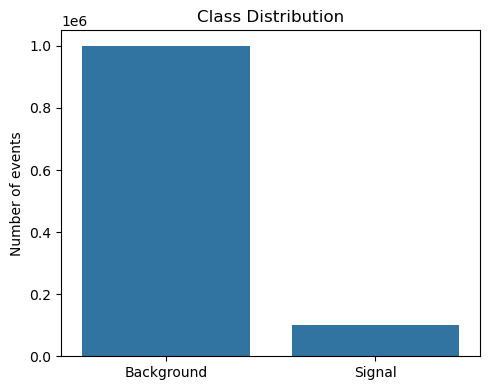


Missing values per variable

No missing values found.


,count,mean,std,min,25%,50%,75%,max
pxj1,1100000.0,-1.327996,1001.399982,-3880.100098,-969.565521,-1.785130,965.911987,3852.429932
pyj1,1100000.0,2.602047,1001.730166,-3320.689941,-966.338516,5.091580,970.291763,3484.770020
pzj1,1100000.0,0.120062,1153.440849,-5587.720215,-723.138016,1.598670,723.789520,6155.580078
mj1,1100000.0,219.599039,164.718074,-0.000026,97.680725,162.915497,299.872986,1615.689941
tau1j1,1100000.0,136.384330,138.257540,0.000000,42.877076,83.727150,177.649502,1473.959961
tau2j1,1100000.0,55.718190,49.405719,0.000000,22.816949,41.430351,71.494202,756.494019
tau3j1,1100000.0,37.420714,29.985560,0.000000,16.197975,29.348351,49.733324,450.463989
pxj2,1100000.0,1.132151,884.772763,-3740.479980,-797.263504,2.593420,800.230484,3630.149902
pyj2,1100000.0,-2.496534,885.154276,-3406.179932,-801.498489,-5.038455,797.962234,3295.419922
pzj2,1100000.0,-0.854074,1163.099093,-5490.729980,-738.085770,0.220583,736.513016,5620.939941


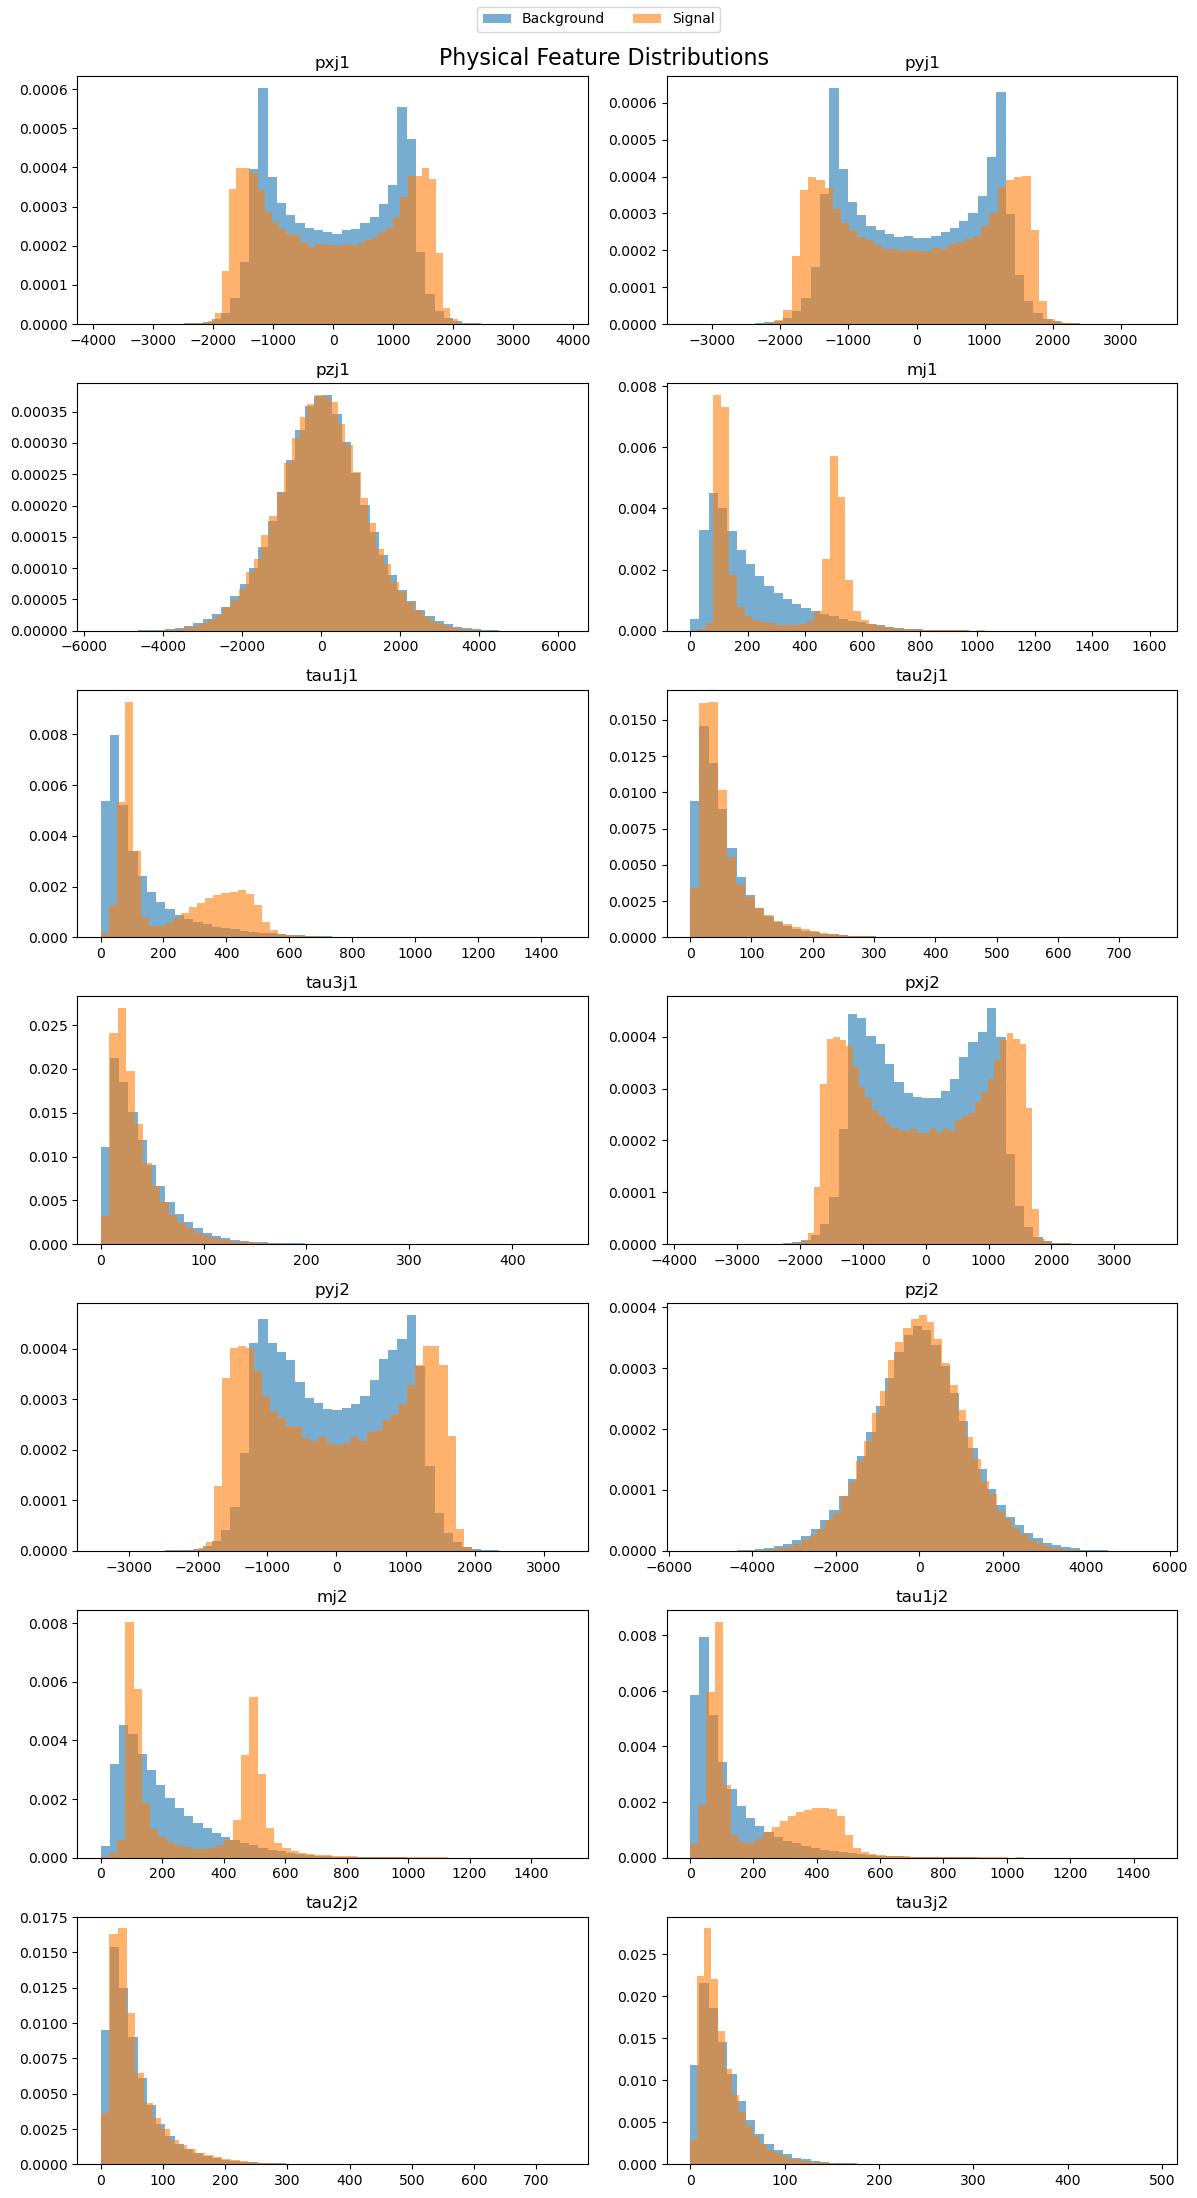

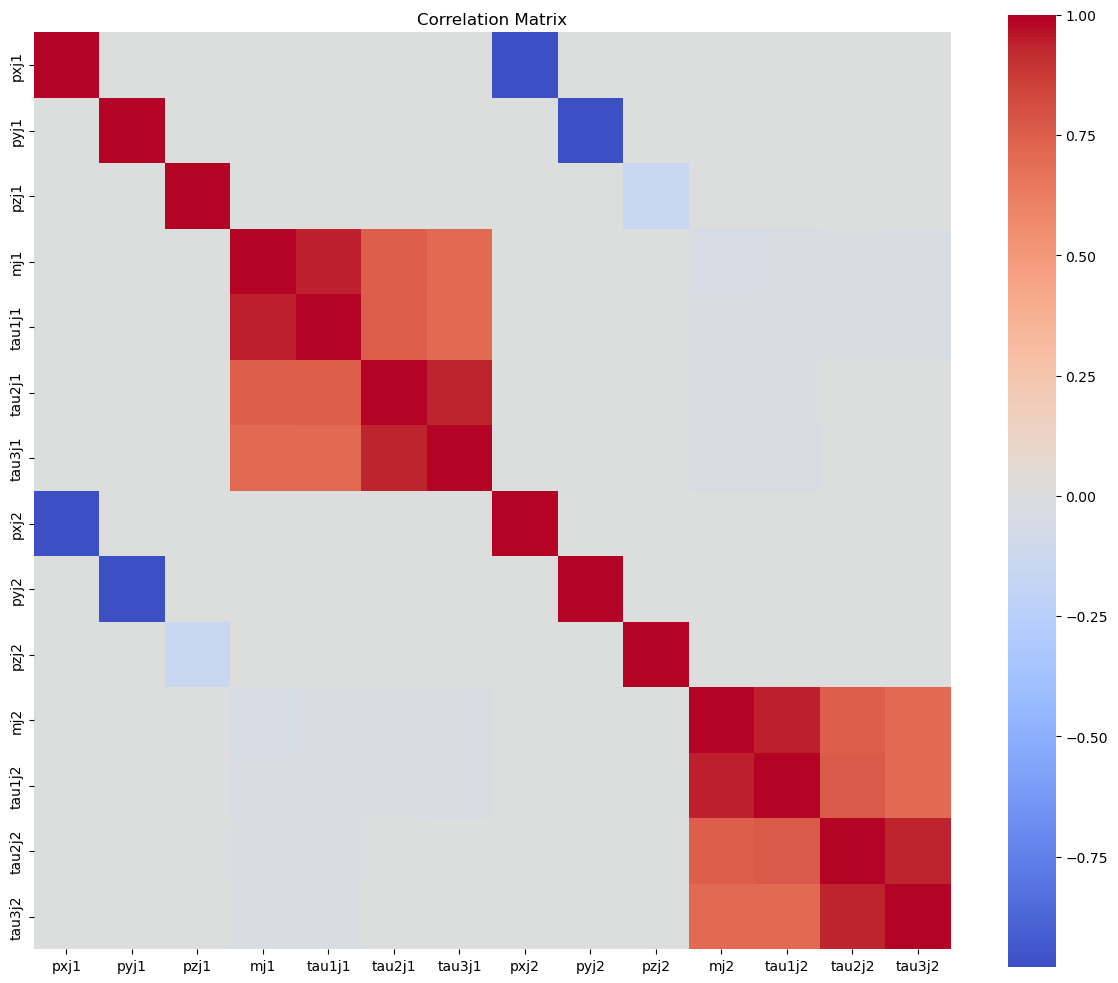

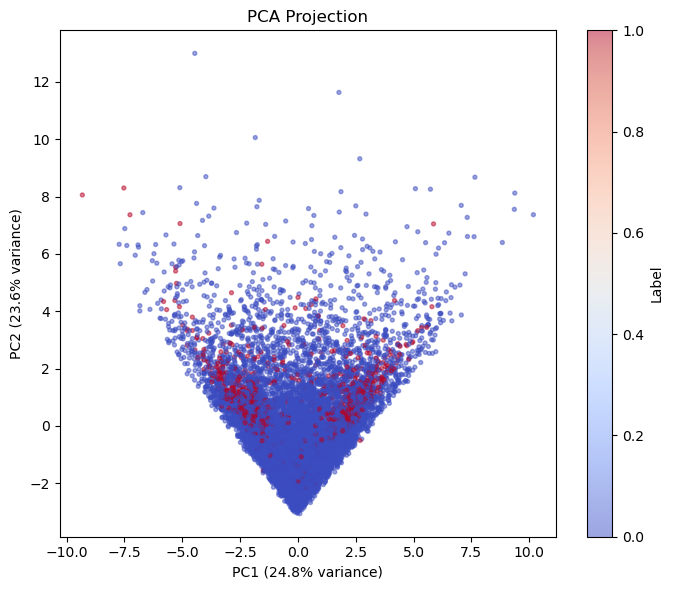

Explained variance: 48.41%


In [28]:
# ----------------------------------------------------------
# Dataset overview
# ----------------------------------------------------------

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Number of events    : {len(df):,}")
print(f"Number of variables : {df.shape[1]-1}")

display(df.head())

# ----------------------------------------------------------
# Separate features and labels
# ----------------------------------------------------------

features = df.drop(columns="label")
labels = df["label"]

background = df[df["label"] == 0]
signal = df[df["label"] == 1]

# ----------------------------------------------------------
# Class distribution
# ----------------------------------------------------------

print("\nClass distribution\n")

print(f"Background events : {(labels == 0).sum():,}")
print(f"Signal events     : {(labels == 1).sum():,}")

plt.figure(figsize=(5,4))

sns.countplot(
    x="label",
    data=df
)

plt.xticks(
    [0,1],
    ["Background","Signal"]
)

plt.xlabel("")
plt.ylabel("Number of events")

plt.title("Class Distribution")

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# Missing values
# ----------------------------------------------------------

missing = df.isnull().sum()

print("\nMissing values per variable\n")

if missing.sum() == 0:
    print("No missing values found.")
else:
    display(missing[missing > 0])

# ----------------------------------------------------------
# Statistical summary
# ----------------------------------------------------------

display(features.describe().T)

# ----------------------------------------------------------
# Feature distributions
# ----------------------------------------------------------

physics_features = features.columns

fig, axes = plt.subplots(
    7,
    2,
    figsize=(12,22)
)

axes = axes.flatten()

for ax, feature in zip(axes, physics_features):

    ax.hist(
        background[feature],
        bins=50,
        density=True,
        alpha=0.6,
        label="Background"
    )

    ax.hist(
        signal[feature],
        bins=50,
        density=True,
        alpha=0.6,
        label="Signal"
    )

    ax.set_title(feature)

for ax in axes[len(physics_features):]:
    ax.remove()

handles, labels_plot = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels_plot,
    loc="upper center",
    ncol=2
)

fig.suptitle(
    "Physical Feature Distributions",
    fontsize=16
)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# Correlation matrix
# ----------------------------------------------------------

plt.figure(figsize=(12,10))

corr = features.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# Random sample for dimensionality reduction
# ----------------------------------------------------------

sample = df.sample(
    n=10000,
    random_state=42
)

X_sample = sample.drop(columns="label")
y_sample = sample["label"]

# ----------------------------------------------------------
# Feature standardization
# ----------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_sample)

# ----------------------------------------------------------
# PCA visualization
# ----------------------------------------------------------

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_sample,
    cmap="coolwarm",
    s=8,
    alpha=0.5
)

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)"
)

plt.title("PCA Projection")

plt.colorbar(label="Label")

plt.tight_layout()

plt.show()

print(
    f"Explained variance: "
    f"{100*pca.explained_variance_ratio_.sum():.2f}%"
)

## Block 4 — Data Preprocessing
Preprocesses the LHC Olympics dataset before training.

The anomaly detection pipeline follows the standard unsupervised approach:

• Background events are used exclusively for training.

• A fraction of the background is reserved for validation.

• The test set contains both background and signal events.

All input variables are standardized using statistics computed only
from the training background in order to avoid information leakage.

In [29]:
# ----------------------------------------------------------
# Separate features and labels
# ----------------------------------------------------------

X = df.drop(columns="label")
y = df["label"]

# ----------------------------------------------------------
# Background and signal events
# ----------------------------------------------------------

background = X[y == 0]
signal = X[y == 1]

print("=" * 60)
print("DATA SPLITTING")
print("=" * 60)

print(f"Background events : {len(background):,}")
print(f"Signal events     : {len(signal):,}")

# ----------------------------------------------------------
# Training / validation split
# ----------------------------------------------------------

X_train, X_val = train_test_split(
    background,
    test_size=PARAMS["val_size"],
    random_state=42,
    shuffle=True
)

# ----------------------------------------------------------
# Test set
# ----------------------------------------------------------

X_test = X.copy()
y_test = y.copy()

# ----------------------------------------------------------
# Feature normalization
# ----------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

# ----------------------------------------------------------
# Convert NumPy arrays to PyTorch tensors
# ----------------------------------------------------------

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

y_test_tensor  = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.float32
)

# ----------------------------------------------------------
# Build TensorDatasets
# ----------------------------------------------------------

train_dataset = TensorDataset(X_train_tensor)

val_dataset = TensorDataset(X_val_tensor)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# ----------------------------------------------------------
# Build DataLoaders
# ----------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=PARAMS["batch_size"],
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=PARAMS["batch_size"],
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=PARAMS["batch_size"],
    shuffle=False,
)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("\nPyTorch DataLoaders")

print(f"Training batches   : {len(train_loader):,}")
print(f"Validation batches : {len(val_loader):,}")
print(f"Testing batches    : {len(test_loader):,}")

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("\nDataset summary")

print(f"Training background   : {X_train.shape}")
print(f"Validation background : {X_val.shape}")
print(f"Testing events        : {X_test.shape}")

print("\nNormalization completed using training statistics only.")

DATA SPLITTING
Background events : 1,000,000
Signal events     : 100,000

PyTorch DataLoaders
Training batches   : 6,641
Validation batches : 1,172
Testing batches    : 8,594

Dataset summary
Training background   : (850000, 14)
Validation background : (150000, 14)
Testing events        : (1100000, 14)

Normalization completed using training statistics only.


## Block 5 — Autoencoder Architecture
Fully-connected Autoencoder for anomaly detection.

The network is trained to reconstruct Standard Model background events.

After training, events producing a large reconstruction error are
considered anomalous, since they differ from the learned background
distribution.

In [30]:
# ----------------------------------------------------------
# Autoencoder
# ----------------------------------------------------------

class Autoencoder(nn.Module):
    """
    Fully-connected Autoencoder.

    Encoder:
        Input
            ↓
        Linear
            ↓
        BatchNorm
            ↓
        ReLU
            ↓
        Linear
            ↓
        ReLU
            ↓
        Latent space

    Decoder:
        Latent
            ↓
        Linear
            ↓
        ReLU
            ↓
        Linear
            ↓
        BatchNorm
            ↓
        ReLU
            ↓
        Linear
            ↓
        Reconstruction
    """

    def __init__(self, input_dim, latent_dim):

        super().__init__()

        # ---------------- Encoder ----------------

        self.encoder = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, latent_dim)

        )

        # ---------------- Decoder ----------------

        self.decoder = nn.Sequential(

            nn.Linear(latent_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, input_dim)

        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):

        z = self.encode(x)

        reconstruction = self.decode(z)

        return reconstruction


# ----------------------------------------------------------
# Instantiate model
# ----------------------------------------------------------

input_dim = X_train.shape[1]

model = Autoencoder(
    input_dim=input_dim,
    latent_dim=PARAMS["latent_dim"]
).to(device)

print(model)

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"\nInput dimension      : {input_dim}")
print(f"Latent dimension     : {PARAMS['latent_dim']}")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=14, bias=True)
  )
)

Input dimension      : 14
Latent dimension     : 8
Total parameters     : 6,870
Trainable parameters : 6,870


## Block 6 — Training and Evaluation Functions
Training utilities for the Autoencoder.

The model minimizes the reconstruction error of background events.

In [31]:
criterion = nn.MSELoss()

# ----------------------------------------------------------
# Training
# ----------------------------------------------------------

def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0.0

    for (x,) in loader:

        x = x.to(device)

        optimizer.zero_grad()

        reconstruction = model(x)

        loss = criterion(reconstruction, x)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)


# ----------------------------------------------------------
# Validation
# ----------------------------------------------------------

def evaluate(model, loader, criterion, device):
    """
    Computes the average reconstruction loss over a dataset.
    """

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for (x,) in loader:

            x = x.to(device)

            reconstruction = model(x)

            loss = criterion(reconstruction, x)

            running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)


# ----------------------------------------------------------
# Reconstruction error
# ----------------------------------------------------------

def reconstruction_error(model, loader, device):

    """
    Computes the reconstruction error for every event.

    Returns
    -------
    errors : ndarray
        Mean squared reconstruction error.
    """

    model.eval()

    errors = []

    with torch.no_grad():

        for batch in loader:

            x = batch[0].to(device)

            reconstruction = model(x)

            mse = torch.mean(
                (reconstruction - x) ** 2,
                dim=1
            )

            errors.extend(
                mse.cpu().numpy()
            )

    return np.array(errors)


print("Training functions successfully defined.")

Training functions successfully defined.


## Block 7 — Autoencoder Training
Training of the Autoencoder.

The model is trained exclusively using Standard Model background events.

The objective is to minimize the reconstruction error on normal events.
Events that cannot be accurately reconstructed will later be considered
candidate anomalies.

Training includes:

• Adam optimizer

• Mean Squared Error (MSE) loss

• Learning-rate scheduling

• Early stopping

• Best-model checkpointing

In [32]:
# ----------------------------------------------------------
# Checkpoint directory
# ----------------------------------------------------------

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

BEST_MODEL_PATH = CHECKPOINT_DIR / "best_autoencoder.pt"

# ----------------------------------------------------------
# Loss function
# ----------------------------------------------------------

criterion = nn.MSELoss()

# ----------------------------------------------------------
# Optimizer
# ----------------------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=PARAMS["lr"]
)

# ----------------------------------------------------------
# Learning-rate scheduler
# ----------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

# ----------------------------------------------------------
# Training history
# ----------------------------------------------------------

history = {
    "loss": [],
    "val_loss": [],
}

best_val_loss = float("inf")
best_weights = copy.deepcopy(model.state_dict())
patience_counter = 0

print("="*65)
print("Starting Autoencoder training")
print("="*65)

t0 = time.time()

# ----------------------------------------------------------
# Training loop
# ----------------------------------------------------------

for epoch in range(PARAMS["epochs"]):

    epoch_start = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
    )

    val_loss = evaluate(
        model,
        val_loader,
        criterion,
        device,
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    marker = ""

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())

        torch.save(best_weights, BEST_MODEL_PATH)

        patience_counter = 0
        marker = "  <-- best model"

    else:

        patience_counter += 1

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch+1:3d}/{PARAMS['epochs']} | "
        f"loss={train_loss:.6f} | "
        f"val_loss={val_loss:.6f} | "
        f"lr={current_lr:.2e} | "
        f"time={epoch_time:.1f}s"
        f"{marker}"
    )

    if patience_counter >= PARAMS["patience"]:

        print("\nEarly stopping triggered.")
        break

# ----------------------------------------------------------
# Load best model
# ----------------------------------------------------------

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

total_time = time.time() - t0

print("\n" + "="*65)
print("Training completed")
print("="*65)

print(f"Best validation loss : {best_val_loss:.6f}")
print(f"Training time        : {total_time:.1f} s")
print(f"Best model saved at  : {BEST_MODEL_PATH}")

Starting Autoencoder training
Epoch   1/50 | loss=0.039458 | val_loss=0.017475 | lr=1.00e-03 | time=43.2s  <-- best model
Epoch   2/50 | loss=0.027099 | val_loss=0.016033 | lr=1.00e-03 | time=38.7s  <-- best model
Epoch   3/50 | loss=0.025484 | val_loss=0.016770 | lr=1.00e-03 | time=35.7s
Epoch   4/50 | loss=0.024410 | val_loss=0.015713 | lr=1.00e-03 | time=35.7s  <-- best model
Epoch   5/50 | loss=0.023677 | val_loss=0.014189 | lr=1.00e-03 | time=35.8s  <-- best model
Epoch   6/50 | loss=0.023164 | val_loss=0.012846 | lr=1.00e-03 | time=35.8s  <-- best model
Epoch   7/50 | loss=0.022848 | val_loss=0.013518 | lr=1.00e-03 | time=35.2s
Epoch   8/50 | loss=0.022362 | val_loss=0.013569 | lr=1.00e-03 | time=35.3s
Epoch   9/50 | loss=0.021881 | val_loss=0.013261 | lr=1.00e-03 | time=35.6s
Epoch  10/50 | loss=0.021631 | val_loss=0.012513 | lr=1.00e-03 | time=35.7s  <-- best model
Epoch  11/50 | loss=0.021499 | val_loss=0.012779 | lr=1.00e-03 | time=35.7s
Epoch  12/50 | loss=0.021169 | val_los

## Block 8 — Learning Curves
Visualizes the Autoencoder learning curves.

The reconstruction loss is monitored on both the training and
validation sets throughout the optimization process.

A small gap between both curves indicates good generalization,
whereas a large divergence may indicate overfitting.

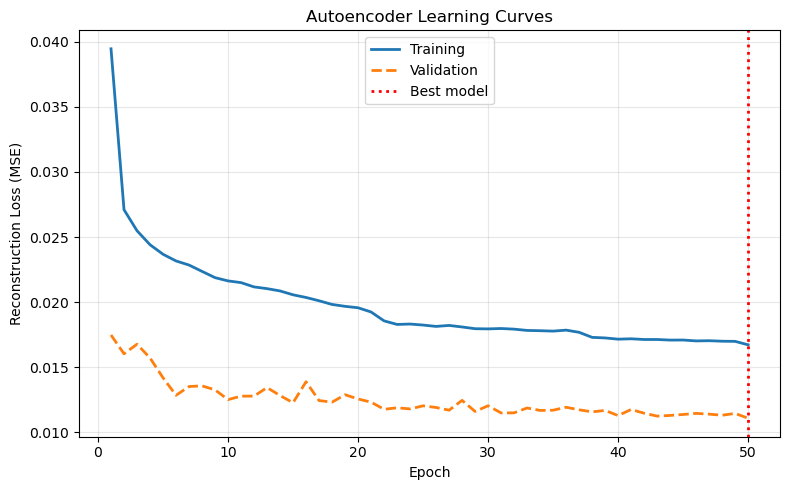

TRAINING SUMMARY
Best epoch            : 50
Training loss         : 0.016722
Validation loss       : 0.011081
Best validation loss  : 0.011081


In [33]:
# ----------------------------------------------------------
# Learning curves
# ----------------------------------------------------------

epochs = range(1, len(history["loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["loss"],
    label="Training",
    linewidth=2,
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation",
    linewidth=2,
    linestyle="--",
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (MSE)")
plt.title("Autoencoder Learning Curves")

plt.grid(alpha=0.3)
plt.legend()

best_epoch = np.argmin(history["val_loss"]) + 1

plt.axvline(
    best_epoch,
    color="red",
    linestyle=":",
    linewidth=2,
    label="Best model",
)

plt.legend()

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Final training summary
# ----------------------------------------------------------

best_epoch = np.argmin(history["val_loss"]) + 1

print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

print(f"Best epoch            : {best_epoch}")
print(f"Training loss         : {history['loss'][-1]:.6f}")
print(f"Validation loss       : {history['val_loss'][-1]:.6f}")
print(f"Best validation loss  : {min(history['val_loss']):.6f}")

## Block 9 — Reconstruction Error
Reconstruction error analysis.

The Autoencoder has been trained exclusively on background events.

If the model has successfully learned the background distribution,
background events should exhibit a small reconstruction error, whereas
signal events should be reconstructed less accurately and therefore
produce larger errors.

This reconstruction error constitutes the anomaly score used throughout
the rest of the analysis.

RECONSTRUCTION ERROR
Background events : 1,000,000
Signal events     : 100,000

Mean reconstruction error
Background : 1.104011e-02
Signal     : 2.111058e-02

Median reconstruction error
Background : 6.720587e-03
Signal     : 1.703876e-02


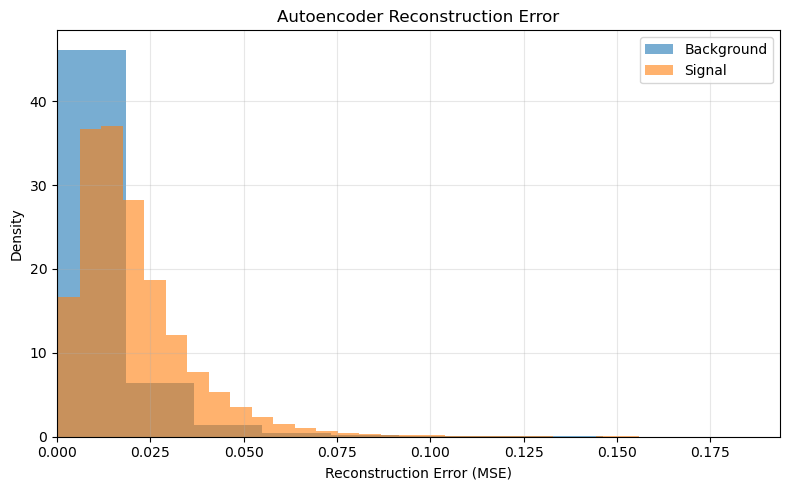


99th percentile threshold : 6.453901e-02


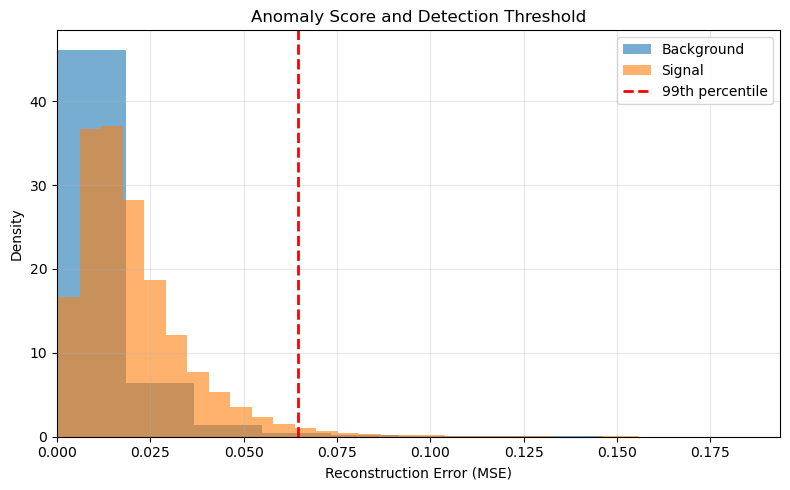

In [34]:
# ----------------------------------------------------------
# Reconstruction errors
# ----------------------------------------------------------

ae_scores = reconstruction_error(
    model,
    test_loader,
    device
)

background_errors = ae_scores[y_test == 0]
signal_errors = ae_scores[y_test == 1]

# ----------------------------------------------------------
# Summary statistics
# ----------------------------------------------------------

print("=" * 60)
print("RECONSTRUCTION ERROR")
print("=" * 60)

print(f"Background events : {len(background_errors):,}")
print(f"Signal events     : {len(signal_errors):,}")

print("\nMean reconstruction error")

print(f"Background : {background_errors.mean():.6e}")
print(f"Signal     : {signal_errors.mean():.6e}")

print("\nMedian reconstruction error")

print(f"Background : {np.median(background_errors):.6e}")
print(f"Signal     : {np.median(signal_errors):.6e}")

# ----------------------------------------------------------
# Reconstruction error distribution
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    background_errors,
    bins=100,
    density=True,
    alpha=0.6,
    label="Background"
)

plt.hist(
    signal_errors,
    bins=100,
    density=True,
    alpha=0.6,
    label="Signal"
)

threshold = np.percentile(
    background_errors,
    PARAMS["percentile"]
)

plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")

plt.title("Autoencoder Reconstruction Error")

plt.legend()

plt.grid(alpha=0.3)

plt.xlim(
    0,
    threshold * 3
)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# Threshold used in later analyses
# ----------------------------------------------------------

threshold = np.percentile(
    background_errors,
    PARAMS["percentile"]
)

print(f"\n{PARAMS['percentile']}th percentile threshold : {threshold:.6e}")

plt.figure(figsize=(8,5))

plt.hist(
    background_errors,
    bins=100,
    density=True,
    alpha=0.6,
    label="Background"
)

plt.hist(
    signal_errors,
    bins=100,
    density=True,
    alpha=0.6,
    label="Signal"
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"{PARAMS['percentile']}th percentile"
)

plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")

plt.title("Anomaly Score and Detection Threshold")

plt.legend()

plt.grid(alpha=0.3)

plt.xlim(
    0,
    threshold * 3
)

plt.tight_layout()

plt.show()

## Block 10 — Isolation Forest
Isolation Forest anomaly detector.

Isolation Forest is a classical unsupervised anomaly detection algorithm.

Unlike the Autoencoder, which learns to reconstruct normal events,
Isolation Forest isolates anomalous observations through random
partitioning of the feature space.

The model is trained exclusively on background events and then
evaluated on the complete test dataset.

ISOLATION FOREST
Training completed.

Background events : 1,000,000
Signal events     : 100,000

Mean anomaly score
Background : 4.516336e-01
Signal     : 4.935608e-01

Median anomaly score
Background : 4.385792e-01
Signal     : 4.925890e-01


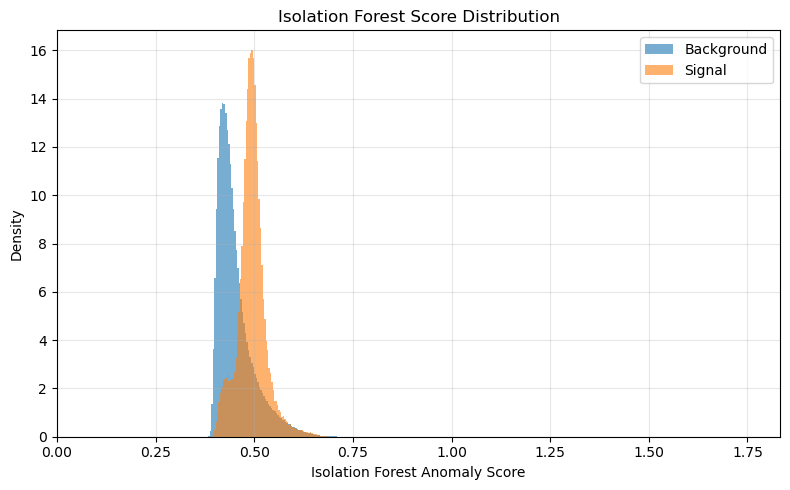


99th percentile threshold : 6.108121e-01


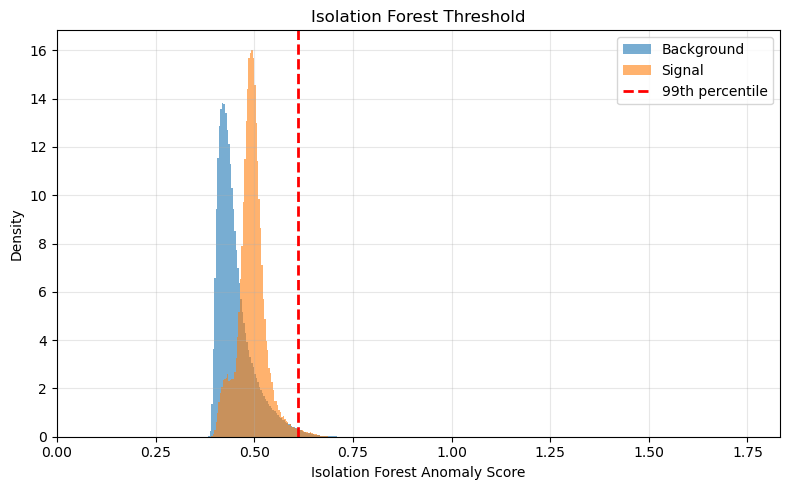

In [35]:
# ----------------------------------------------------------
# Train Isolation Forest
# ----------------------------------------------------------

iforest = IsolationForest(

    n_estimators=PARAMS["n_estimators"],
    contamination=PARAMS["contamination"],
    random_state=42,
    n_jobs=-1,

)

iforest.fit(X_train)

print("=" * 60)
print("ISOLATION FOREST")
print("=" * 60)

print("Training completed.")

# ----------------------------------------------------------
# Compute anomaly scores
# ----------------------------------------------------------

"""
score_samples() assigns larger values to normal events.

To facilitate comparison with the Autoencoder, the sign is inverted so
that larger values correspond to more anomalous events.
"""

iforest_scores = -iforest.score_samples(X_test)

background_iforest = iforest_scores[y_test == 0]
signal_iforest = iforest_scores[y_test == 1]

# ----------------------------------------------------------
# Summary statistics
# ----------------------------------------------------------

print(f"\nBackground events : {len(background_iforest):,}")
print(f"Signal events     : {len(signal_iforest):,}")

print("\nMean anomaly score")

print(f"Background : {background_iforest.mean():.6e}")
print(f"Signal     : {signal_iforest.mean():.6e}")

print("\nMedian anomaly score")

print(f"Background : {np.median(background_iforest):.6e}")
print(f"Signal     : {np.median(signal_iforest):.6e}")

# ----------------------------------------------------------
# Score distributions
# ----------------------------------------------------------

iforest_threshold = np.percentile(

    background_iforest,
    PARAMS["percentile"]

)

plt.figure(figsize=(8,5))

plt.hist(

    background_iforest,
    bins=100,
    density=True,
    alpha=0.6,
    label="Background",

)

plt.hist(

    signal_iforest,
    bins=100,
    density=True,
    alpha=0.6,
    label="Signal",

)

plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Density")

plt.title("Isolation Forest Score Distribution")

plt.grid(alpha=0.3)

plt.legend()

plt.xlim(
    0,
    iforest_threshold * 3
)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# Threshold
# ----------------------------------------------------------

iforest_threshold = np.percentile(

    background_iforest,
    PARAMS["percentile"]

)

print(
    f"\n{PARAMS['percentile']}th percentile threshold : "
    f"{iforest_threshold:.6e}"
)

plt.figure(figsize=(8,5))

plt.hist(

    background_iforest,
    bins=100,
    density=True,
    alpha=0.6,
    label="Background",

)

plt.hist(

    signal_iforest,
    bins=100,
    density=True,
    alpha=0.6,
    label="Signal",

)

plt.axvline(

    iforest_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"{PARAMS['percentile']}th percentile",

)

plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Density")

plt.title("Isolation Forest Threshold")

plt.grid(alpha=0.3)

plt.legend()

plt.xlim(
    0,
    iforest_threshold * 3
)

plt.tight_layout()

plt.show()

## Block 11 — ROC Curves
Receiver Operating Characteristic (ROC) analysis.

This section compares the anomaly detection performance of the two
unsupervised methods implemented in this project:

• Autoencoder
• Isolation Forest

The ROC curve illustrates the trade-off between the True Positive Rate
(TPR) and the False Positive Rate (FPR) for every possible decision
threshold.

The Area Under the Curve (AUC) provides a threshold-independent
performance metric, where values closer to one indicate better
discrimination between background and signal events.

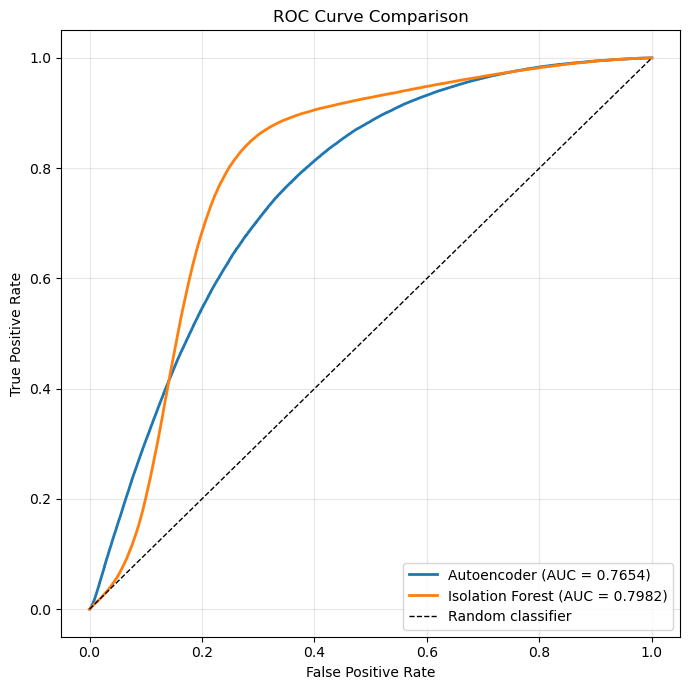

ROC PERFORMANCE
Autoencoder AUC      : 0.7654
Isolation Forest AUC : 0.7982

Best detector: Isolation Forest


In [36]:
# ----------------------------------------------------------
# ROC curves
# ----------------------------------------------------------

fpr_ae, tpr_ae, _ = roc_curve(
    y_test,
    ae_scores
)

fpr_if, tpr_if, _ = roc_curve(
    y_test,
    iforest_scores
)

auc_ae = auc(
    fpr_ae,
    tpr_ae
)

auc_if = auc(
    fpr_if,
    tpr_if
)

# ----------------------------------------------------------
# ROC comparison
# ----------------------------------------------------------

plt.figure(figsize=(7,7))

plt.plot(
    fpr_ae,
    tpr_ae,
    linewidth=2,
    label=f"Autoencoder (AUC = {auc_ae:.4f})"
)

plt.plot(
    fpr_if,
    tpr_if,
    linewidth=2,
    label=f"Isolation Forest (AUC = {auc_if:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    "k--",
    linewidth=1,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.grid(alpha=0.3)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# Performance summary
# ----------------------------------------------------------

print("=" * 60)
print("ROC PERFORMANCE")
print("=" * 60)

print(f"Autoencoder AUC      : {auc_ae:.4f}")
print(f"Isolation Forest AUC : {auc_if:.4f}")

# ----------------------------------------------------------
# Best-performing method
# ----------------------------------------------------------

if auc_ae > auc_if:

    print("\nBest detector: Autoencoder")

elif auc_if > auc_ae:

    print("\nBest detector: Isolation Forest")

else:

    print("\nBoth methods achieved identical AUC.")

## Block 12 — Threshold Study
Threshold sensitivity analysis.

The anomaly detector converts a continuous anomaly score into a binary
classification by applying a decision threshold.

This section studies how the operating point changes as the threshold
becomes more or less restrictive.

The following metrics are evaluated:

• True Positive Rate (Signal efficiency)

• False Positive Rate

• Background rejection

using several percentiles of the background reconstruction-error
distribution.

,Percentile,AE TPR,AE FPR,AE Background rejection,IF TPR,IF FPR,IF Background rejection
0,95.0,0.15414,0.050000,0.950000,0.05938,0.050,0.950
1,97.0,0.08925,0.030001,0.969999,0.03140,0.030,0.970
2,98.0,0.05459,0.020000,0.980000,0.02006,0.020,0.980
3,99.0,0.02134,0.010000,0.990000,0.01050,0.010,0.990
4,99.5,0.00845,0.005000,0.995000,0.00520,0.005,0.995


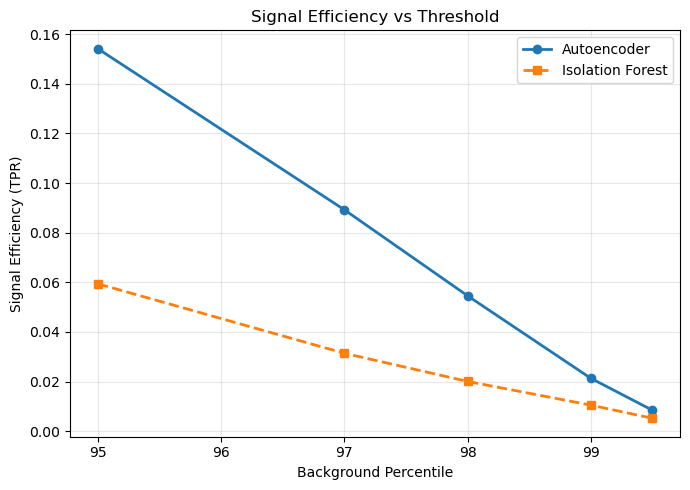

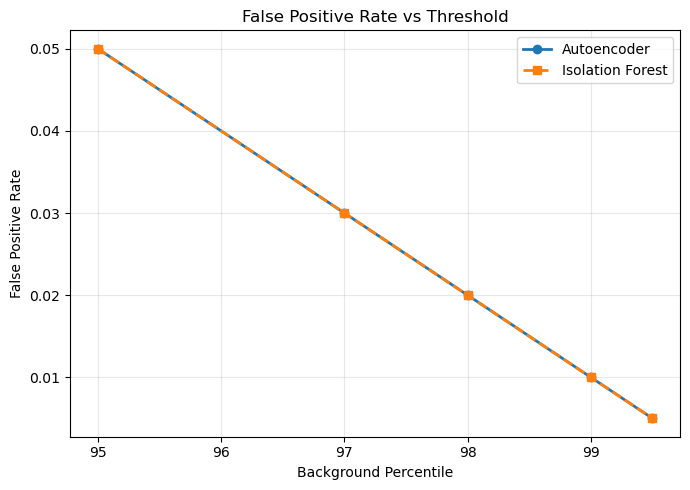

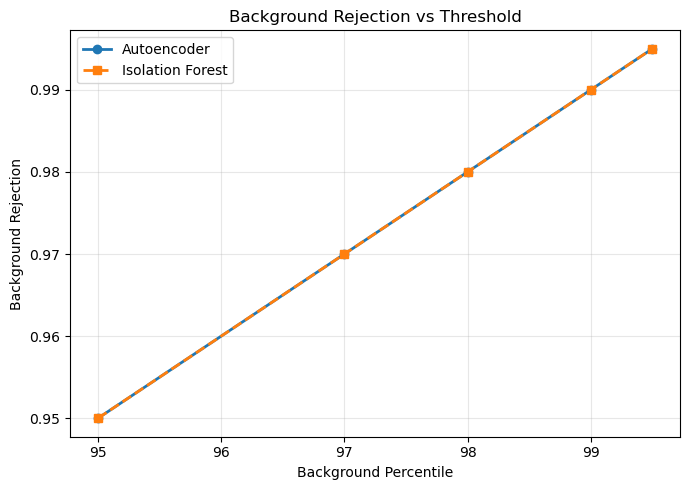

In [37]:
# ----------------------------------------------------------
# Thresholds
# ----------------------------------------------------------

percentiles = [95, 97, 98, 99, 99.5]

results = []

# ----------------------------------------------------------
# Threshold study
# ----------------------------------------------------------

for percentile in percentiles:

    # ---------------- Autoencoder ----------------

    ae_threshold = np.percentile(
        background_errors,
        percentile
    )

    ae_prediction = ae_scores >= ae_threshold

    TP = np.sum((ae_prediction == 1) & (y_test == 1))
    FP = np.sum((ae_prediction == 1) & (y_test == 0))
    TN = np.sum((ae_prediction == 0) & (y_test == 0))
    FN = np.sum((ae_prediction == 0) & (y_test == 1))

    ae_tpr = TP / (TP + FN)
    ae_fpr = FP / (FP + TN)

    # ---------------- Isolation Forest ----------------

    if_threshold = np.percentile(
        background_iforest,
        percentile
    )

    if_prediction = iforest_scores >= if_threshold

    TP = np.sum((if_prediction == 1) & (y_test == 1))
    FP = np.sum((if_prediction == 1) & (y_test == 0))
    TN = np.sum((if_prediction == 0) & (y_test == 0))
    FN = np.sum((if_prediction == 0) & (y_test == 1))

    if_tpr = TP / (TP + FN)
    if_fpr = FP / (FP + TN)

    results.append([

        percentile,

        ae_tpr,
        ae_fpr,
        1-ae_fpr,

        if_tpr,
        if_fpr,
        1-if_fpr

    ])

# ----------------------------------------------------------
# Results table
# ----------------------------------------------------------

results = pd.DataFrame(

    results,

    columns=[

        "Percentile",

        "AE TPR",
        "AE FPR",
        "AE Background rejection",

        "IF TPR",
        "IF FPR",
        "IF Background rejection"

    ]

)

display(results)

# ----------------------------------------------------------
# Signal efficiency
# ----------------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(
    results["Percentile"],
    results["AE TPR"],
    marker="o",
    linewidth=2,
    linestyle="-",
    label="Autoencoder"
)

plt.plot(
    results["Percentile"],
    results["IF TPR"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Isolation Forest"
)

plt.xlabel("Background Percentile")
plt.ylabel("Signal Efficiency (TPR)")
plt.title("Signal Efficiency vs Threshold")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# False Positive Rate
# ----------------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(
    results["Percentile"],
    results["AE FPR"],
    marker="o",
    linewidth=2,
    linestyle="-",
    label="Autoencoder"
)

plt.plot(
    results["Percentile"],
    results["IF FPR"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Isolation Forest"
)

plt.xlabel("Background Percentile")
plt.ylabel("False Positive Rate")
plt.title("False Positive Rate vs Threshold")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Background rejection
# ----------------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(
    results["Percentile"],
    results["AE Background rejection"],
    marker="o",
    linewidth=2,
    linestyle="-",
    label="Autoencoder"
)

plt.plot(
    results["Percentile"],
    results["IF Background rejection"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Isolation Forest"
)

plt.xlabel("Background Percentile")
plt.ylabel("Background Rejection")
plt.title("Background Rejection vs Threshold")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Block 13 — Robustness Study
Robustness against variations in background composition.

Real detector data rarely follow exactly the same distribution used
during training. Small changes in detector calibration, pile-up,
background composition or reconstruction may alter the event features.

To evaluate the robustness of the anomaly detectors, progressively
stronger Gaussian perturbations are added to the test dataset while the
models remain unchanged.

The degradation in ROC AUC is then monitored for both methods.

ROBUSTNESS STUDY


,Noise std,AE AUC,IF AUC
0,0.00,0.765361,0.798228
1,0.02,0.760806,0.797839
2,0.05,0.735988,0.795929
3,0.10,0.642803,0.789755
4,0.20,0.355411,0.768830


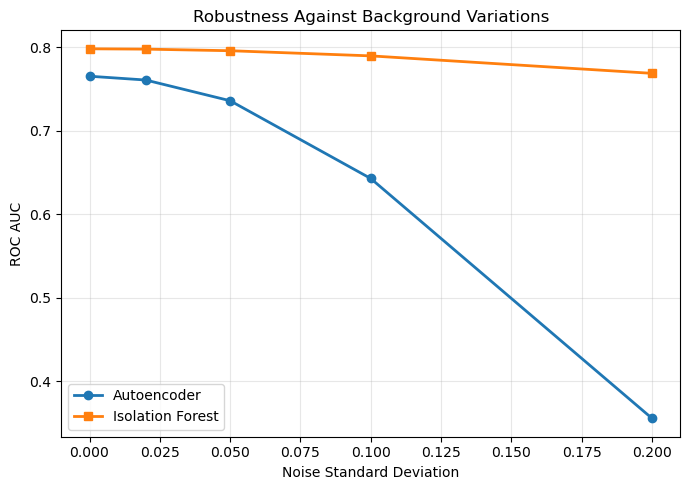

In [38]:
# ----------------------------------------------------------
# Noise levels
# ----------------------------------------------------------

noise_levels = [
    0.00,
    0.02,
    0.05,
    0.10,
    0.20,
]

results = []

# ----------------------------------------------------------
# Robustness study
# ----------------------------------------------------------

rng = np.random.default_rng(42)

for noise_std in noise_levels:

    X_noisy = X_test.copy()

    mask = (y_test == 0)

    background_noise = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=X_noisy[mask].shape
    )

    X_noisy[mask] += background_noise

    # ---------------- Autoencoder ----------------

    noisy_tensor = torch.tensor(
        X_noisy,
        dtype=torch.float32
    )

    noisy_loader = DataLoader(

        TensorDataset(noisy_tensor),

        batch_size=PARAMS["batch_size"],
        shuffle=False

    )

    ae_scores_noisy = reconstruction_error(

        model,
        noisy_loader,
        device

    )

    auc_ae = auc(

        *roc_curve(
            y_test,
            ae_scores_noisy
        )[:2]

    )

    # ---------------- Isolation Forest ----------------

    if_scores_noisy = -iforest.score_samples(
        X_noisy
    )

    auc_if = auc(

        *roc_curve(
            y_test,
            if_scores_noisy
        )[:2]

    )

    results.append([

        noise_std,
        auc_ae,
        auc_if

    ])

# ----------------------------------------------------------
# Results table
# ----------------------------------------------------------

results = pd.DataFrame(

    results,

    columns=[

        "Noise std",
        "AE AUC",
        "IF AUC"

    ]

)

print("=" * 60)
print("ROBUSTNESS STUDY")
print("=" * 60)

display(results)

# ----------------------------------------------------------
# Robustness plot
# ----------------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(

    results["Noise std"],
    results["AE AUC"],

    marker="o",
    linewidth=2,

    label="Autoencoder"

)

plt.plot(

    results["Noise std"],
    results["IF AUC"],

    marker="s",
    linewidth=2,

    label="Isolation Forest"

)

plt.xlabel("Noise Standard Deviation")

plt.ylabel("ROC AUC")

plt.title("Robustness Against Background Variations")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

## Block 14 — Latent Space Visualization
Latent space visualization.

The encoder compresses the original feature space into a low-dimensional
latent representation.

Although the latent space cannot be visualized directly, Principal
Component Analysis (PCA) is applied to project the latent vectors onto
two dimensions.

This visualization illustrates whether the Autoencoder has learned a
representation that separates background and signal events.

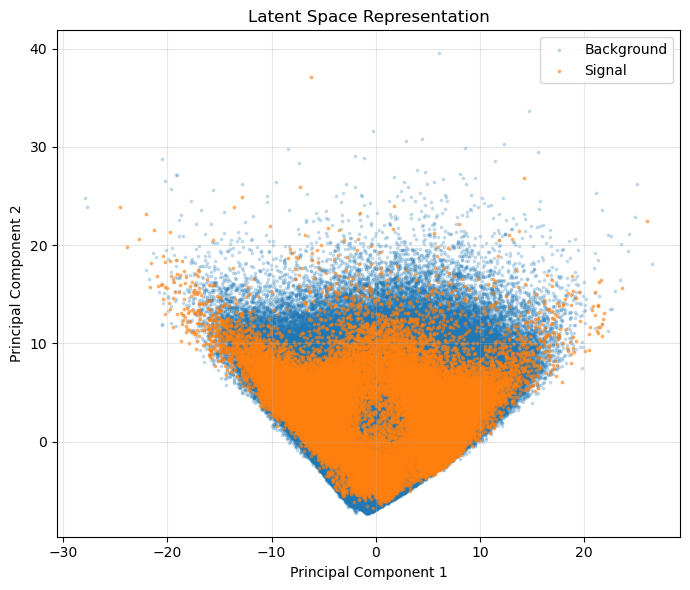

In [39]:
# ----------------------------------------------------------
# Encode test events
# ----------------------------------------------------------

model.eval()

X_tensor = torch.tensor(
    X_test,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    latent = model.encoder(X_tensor)

latent = latent.cpu().numpy()

# ----------------------------------------------------------
# PCA projection
# ----------------------------------------------------------

pca = PCA(
    n_components=2,
    random_state=42
)

latent_2d = pca.fit_transform(latent)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(7,6))

plt.scatter(

    latent_2d[y_test == 0,0],
    latent_2d[y_test == 0,1],

    s=3,
    alpha=0.2,

    label="Background"

)

plt.scatter(

    latent_2d[y_test == 1,0],
    latent_2d[y_test == 1,1],

    s=3,
    alpha=0.5,

    label="Signal"

)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Latent Space Representation")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

## Block 15 — Conclusions
Project summary.

This section summarizes the main findings obtained throughout the
analysis.

In [40]:
print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print(f"\nAutoencoder ROC AUC      : {auc_ae:.4f}")
print(f"Isolation Forest ROC AUC : {auc_if:.4f}")

print(f"\nDefault threshold (AE) : {threshold:.6f}")
print(f"Default threshold (IF) : {iforest_threshold:.6f}")

print("\nOverall conclusion:")

if auc_ae > auc_if:

    print(
        "The Autoencoder achieved the best overall detection performance."
    )

elif auc_if > auc_ae:

    print(
        "Isolation Forest achieved the best overall detection performance."
    )

else:

    print(
        "Both methods achieved comparable performance."
    )

PROJECT SUMMARY

Autoencoder ROC AUC      : 0.3554
Isolation Forest ROC AUC : 0.7688

Default threshold (AE) : 0.064539
Default threshold (IF) : 0.610812

Overall conclusion:
Isolation Forest achieved the best overall detection performance.
